# Inicjalizacja | Wytłumaczalność (Explainable AI)

>>> AKT 1: INICJALIZACJA SYSTEMÓW I WYTŁUMACZALNOŚĆ (XAI) <<<
[+] Pomyślnie załadowano modele RF i XGBoost oraz Label Encoder.
[+] Odtworzono środowisko transdukcyjne: 11 znanych protokołów, 21 znanych stanów.

[*] Generowanie wykresów Feature Importance...


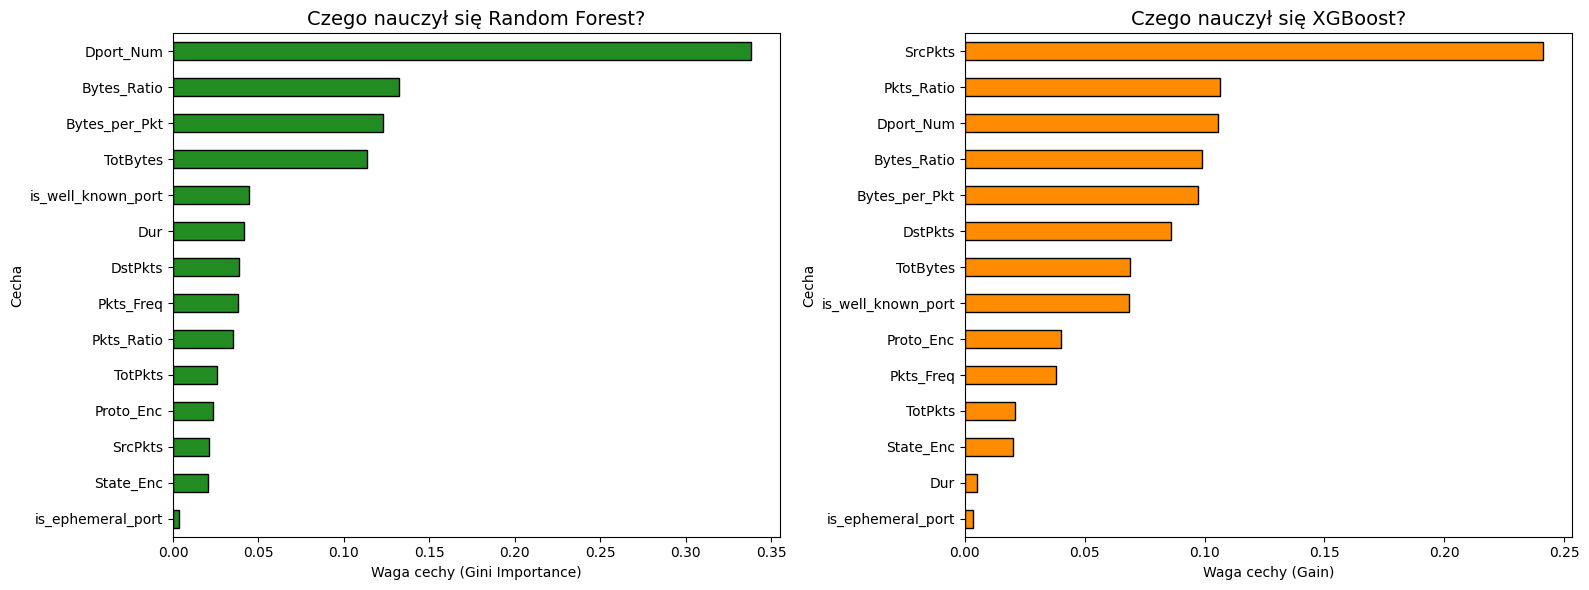


                 TABELA WAŻNOŚCI CECH (FEATURE IMPORTANCE) W %                  
CECHA                  | RANDOM FOREST   | XGBOOST         | ŚREDNIA Z MODELI
---------------------------------------------------------------------------
Dport_Num              |          33.82% |          10.54% |          22.18%
SrcPkts                |           2.12% |          24.10% |          13.11%
Bytes_Ratio            |          13.23% |           9.89% |          11.56%
Bytes_per_Pkt          |          12.27% |           9.71% |          10.99%
TotBytes               |          11.38% |           6.89% |           9.13%
Pkts_Ratio             |           3.53% |          10.63% |           7.08%
DstPkts                |           3.88% |           8.62% |           6.25%
is_well_known_port     |           4.45% |           6.84% |           5.65%
Pkts_Freq              |           3.82% |           3.80% |           3.81%
Proto_Enc              |           2.37% |           4.03% |           

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib

print("="*80)
print(">>> AKT 1: INICJALIZACJA SYSTEMÓW I WYTŁUMACZALNOŚĆ (XAI) <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE MODELI I ENKODERÓW
# ==========================================
model_dir = '../modele'
try:
    rf_model = joblib.load(os.path.join(model_dir, 'rf_production_model.joblib'))
    xgb_model = joblib.load(os.path.join(model_dir, 'xgb_production_model.joblib'))
    le_target = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    print("[+] Pomyślnie załadowano modele RF i XGBoost oraz Label Encoder.")
except Exception as e:
    print(f"[-] Błąd ładowania modeli: {e}. Upewnij się, że wykonałeś Krok 3 w poprzednich notatnikach!")

# ==========================================
# 2. ODTWORZENIE SŁOWNIKÓW I FUNKCJI (BARIERA TRANSDUKCYJNA)
# ==========================================
# Wczytujemy ZAMROŻONE słowniki z dysku. 
# System produkcyjny nie widzi danych treningowych! To eliminuje Data Leakage.
known_protos = joblib.load(os.path.join(model_dir, 'known_protos.joblib'))
known_states = joblib.load(os.path.join(model_dir, 'known_states.joblib'))
print(f"[+] Odtworzono środowisko transdukcyjne: {len(known_protos)} znanych protokołów, {len(known_states)} znanych stanów.")

FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)

def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

def prepare_future_logs(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)

    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
    return df[FEATURES].fillna(0)

# ==========================================
# 3. WIZUALIZACJA FEATURE IMPORTANCE
# ==========================================
print("\n[*] Generowanie wykresów Feature Importance...")
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

df_fi = pd.DataFrame({
    'Cecha': FEATURES,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Cecha')

# Wykresy
df_fi_sorted_rf = df_fi.sort_values(by='Random Forest', ascending=True)
df_fi_sorted_xgb = df_fi.sort_values(by='XGBoost', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_fi_sorted_rf['Random Forest'].plot(kind='barh', ax=ax1, color='forestgreen', edgecolor='black')
ax1.set_title("Czego nauczył się Random Forest?", fontsize=14)
ax1.set_xlabel("Waga cechy (Gini Importance)")

df_fi_sorted_xgb['XGBoost'].plot(kind='barh', ax=ax2, color='darkorange', edgecolor='black')
ax2.set_title("Czego nauczył się XGBoost?", fontsize=14)
ax2.set_xlabel("Waga cechy (Gain)")

plt.tight_layout()
plt.savefig('../wykresy/11_feature_importance_comparison.png', dpi=300)
plt.show()

# ==========================================
# 4. TABELARYCZNE ZESTAWIENIE W PROCENTACH
# ==========================================
print("\n" + "="*80)
print(f"{'TABELA WAŻNOŚCI CECH (FEATURE IMPORTANCE) W %':^80}")
print("="*80)

# Obliczanie procentów (zabezpieczenie dzieleniem)
df_fi_pct = df_fi.copy()
df_fi_pct['RF %'] = (df_fi_pct['Random Forest'] / df_fi_pct['Random Forest'].sum()) * 100
df_fi_pct['XGB %'] = (df_fi_pct['XGBoost'] / df_fi_pct['XGBoost'].sum()) * 100
df_fi_pct['Średnia %'] = (df_fi_pct['RF %'] + df_fi_pct['XGB %']) / 2

# Sortowanie po średniej dla najlepszej czytelności
df_fi_pct = df_fi_pct.sort_values(by='Średnia %', ascending=False)

print(f"{'CECHA':<22} | {'RANDOM FOREST':<15} | {'XGBOOST':<15} | {'ŚREDNIA Z MODELI':<15}")
print("-" * 75)
for index, row in df_fi_pct.iterrows():
    print(f"{index:<22} | {row['RF %']:>14.2f}% | {row['XGB %']:>14.2f}% | {row['Średnia %']:>14.2f}%")
print("="*80 + "\n")

# Weryfikacja dryfu zmiennych


>>> AKT 2: MATEMATYCZNA ANALIZA DRYFU (OUT-OF-DISTRIBUTION) <<<
[*] Wczytywanie przestrzeni treningowej do porównania (baza)...

------------------------------------------------------------
[*] Pobieranie surowych logów z Areny A (Dryf Czasowy)...
[+] Zbudowano surowy zbiór Areny A. Rozmiar: (39112, 118)
[*] Transformacja przestrzeni cech...

[*] ANALIZA CONCEPT DRIFT (KL-DIVERGENCE) DLA: Arena_A...
    - Cecha 'Dur            ': KL-Div = 0.1035 | Stabilny
    - Cecha 'TotPkts        ': KL-Div = 0.6704 | !!! WYKRYTO DRYF !!!
    - Cecha 'TotBytes       ': KL-Div = 2.1870 | !!! WYKRYTO DRYF !!!
    - Cecha 'Bytes_per_Pkt  ': KL-Div = 5.8231 | !!! WYKRYTO DRYF !!!
    - Cecha 'Pkts_Ratio     ': KL-Div = 2.3406 | !!! WYKRYTO DRYF !!!

[ALERT] Wykryto krytyczne przesunięcie pojęć (Concept Drift) na arenie Arena_A!
        Rekomendowana akcja: Wywołanie funkcji rebuild() (Retrenowanie całej przestrzeni nienadzorowanej).
[+] Zapisano wykres dryfu: ../wykresy/12_drift_analysis_Arena_A.png


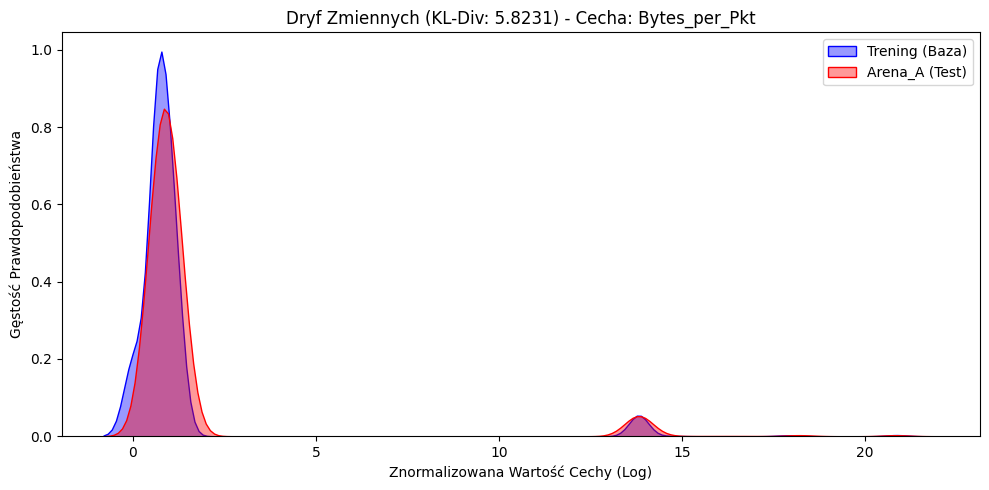


------------------------------------------------------------
[*] Pobieranie surowych logów z Areny B (Dryf Przestrzenny)...
[+] Zbudowano surowy zbiór Areny B. Rozmiar: (43887, 118)
[*] Transformacja przestrzeni cech...

[*] ANALIZA CONCEPT DRIFT (KL-DIVERGENCE) DLA: Arena_B...
    - Cecha 'Dur            ': KL-Div = 3.1779 | !!! WYKRYTO DRYF !!!
    - Cecha 'TotPkts        ': KL-Div = 2.1894 | !!! WYKRYTO DRYF !!!
    - Cecha 'TotBytes       ': KL-Div = 2.6607 | !!! WYKRYTO DRYF !!!
    - Cecha 'Bytes_per_Pkt  ': KL-Div = 9.6646 | !!! WYKRYTO DRYF !!!
    - Cecha 'Pkts_Ratio     ': KL-Div = 2.2356 | !!! WYKRYTO DRYF !!!

[ALERT] Wykryto krytyczne przesunięcie pojęć (Concept Drift) na arenie Arena_B!
        Rekomendowana akcja: Wywołanie funkcji rebuild() (Retrenowanie całej przestrzeni nienadzorowanej).
[+] Zapisano wykres dryfu: ../wykresy/12_drift_analysis_Arena_B.png


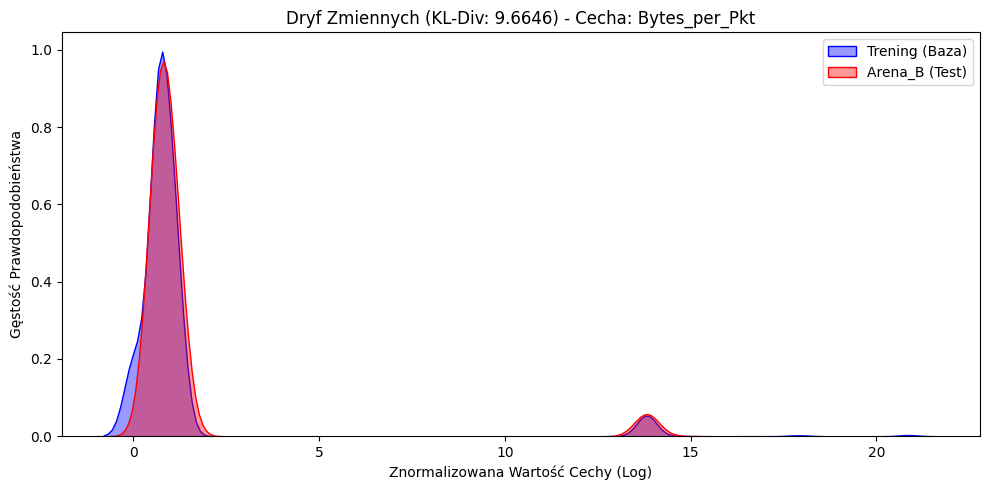

In [2]:
from scipy.special import rel_entr
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import pandas as pd
import numpy as np

print("\n" + "="*80)
print(">>> AKT 2: MATEMATYCZNA ANALIZA DRYFU (OUT-OF-DISTRIBUTION) <<<")
print("="*80)

def monitor_concept_drift(df_train, df_test, numeric_cols, arena_name="Arena OOD", drift_threshold=0.5):
    print(f"\n[*] ANALIZA CONCEPT DRIFT (KL-DIVERGENCE) DLA: {arena_name}...")
    kl_results = {}

    for col in numeric_cols:
        # Bierzemy dane, odrzucamy zera do analizy dystrybucji
        data_train = df_train[df_train[col] > 0][col].dropna()
        data_test = df_test[df_test[col] > 0][col].dropna()
        
        if len(data_train) == 0 or len(data_test) == 0:
            continue

        # Przygotowanie histogramów (rozkładów prawdopodobieństwa)
        train_dist, edges = np.histogram(data_train, bins=50, density=True)
        test_dist, _ = np.histogram(data_test, bins=edges, density=True)
        
        # Normalizacja (unikamy dzielenia przez zero)
        train_dist = np.where(train_dist == 0, 1e-10, train_dist)
        test_dist = np.where(test_dist == 0, 1e-10, test_dist)
        
        # Obliczanie KL-Divergence
        kl_div = np.sum(rel_entr(train_dist, test_dist))
        kl_results[col] = kl_div
        
        status = "!!! WYKRYTO DRYF !!!" if kl_div > drift_threshold else "Stabilny"
        print(f"    - Cecha '{col:<15}': KL-Div = {kl_div:.4f} | {status}")

    if not kl_results:
        print("Brak danych do analizy dryfu.")
        return

    # LOGIKA DECYZYJNA (Wyzwalacz Retrenowania zdefiniowany w recenzji)
    max_drift = max(kl_results.values())
    if max_drift > drift_threshold:
        print(f"\n[ALERT] Wykryto krytyczne przesunięcie pojęć (Concept Drift) na arenie {arena_name}!")
        print("        Rekomendowana akcja: Wywołanie funkcji rebuild() (Retrenowanie całej przestrzeni nienadzorowanej).")
    
    # Opcjonalne przypięcie biblioteki OTDD (Optimal Transport Dataset Distance)
    # dystans Wassersteina w geometrii przestrzeni całego rzutu
    # dist_otdd = DatasetDistance(loaders_src, loaders_tgt, inner_ot_method='exact').distance()
    
    # Szukamy cechy, która zmieniła się najbardziej do wykresu
    max_drift_feature = max(kl_results, key=kl_results.get)
    
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data_train, label='Trening (Baza)', fill=True, alpha=0.4, color='blue')
    sns.kdeplot(data_test, label=f'{arena_name} (Test)', fill=True, alpha=0.4, color='red')
    plt.title(f"Dryf Zmiennych (KL-Div: {kl_results[max_drift_feature]:.4f}) - Cecha: {max_drift_feature}")
    plt.xlabel("Znormalizowana Wartość Cechy (Log)")
    plt.ylabel("Gęstość Prawdopodobieństwa")
    plt.legend()
    plt.tight_layout()
    
    save_path = f'../wykresy/12_drift_analysis_{arena_name.replace(" ", "_")}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[+] Zapisano wykres dryfu: {save_path}")
    plt.show()
    
    return kl_results

# ==========================================
# 1. PRZYGOTOWANIE BAZY (ZBIÓR TRENINGOWY DO TESTU DRYFU)
# ==========================================
print("[*] Wczytywanie przestrzeni treningowej do porównania (baza)...")
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

# Cechy numeryczne poddawane testowi statystycznemu (nie potrzebujemy tu protokołów)
num_features_to_test = ['Dur', 'TotPkts', 'TotBytes', 'Bytes_per_Pkt', 'Pkts_Ratio']

# Ekstrakcja zlogarytmowanej bazy (ominięcie błędu kolumn kategorycznych)
X_train = df_train_raw[num_features_to_test].fillna(0)

# ==========================================
# 2. ANALIZA ARENY A (DRYF CZASOWY - PRZYSZŁOŚĆ)
# ==========================================
print("\n" + "-"*60)
print("[*] Pobieranie surowych logów z Areny A (Dryf Czasowy)...")
arena_a_files = glob.glob("../dane/testowe_A/*_netflow-extended.csv") 

dfs_arena_a = []
for f in arena_a_files[:5]: # Bierzemy próbkę
    dfs_arena_a.append(pd.read_csv(f, on_bad_lines='skip', low_memory=False))

if dfs_arena_a:
    df_arena_a_raw = pd.concat(dfs_arena_a, ignore_index=True)
    print(f"[+] Zbudowano surowy zbiór Areny A. Rozmiar: {df_arena_a_raw.shape}")
    print("[*] Transformacja przestrzeni cech...")
    X_arena_a = prepare_future_logs(df_arena_a_raw)
    monitor_concept_drift(X_train, X_arena_a, num_features_to_test, "Arena_A")
else:
    print("[-] Nie znaleziono plików Areny A!")

# ==========================================
# 3. ANALIZA ARENY B (DRYF PRZESTRZENNY - AZJA)
# ==========================================
print("\n" + "-"*60)
print("[*] Pobieranie surowych logów z Areny B (Dryf Przestrzenny)...")
arena_b_files = glob.glob("../dane/testowe_B/*_netflow-extended.csv") 

dfs_arena_b = []
for f in arena_b_files[:5]: 
    dfs_arena_b.append(pd.read_csv(f, on_bad_lines='skip', low_memory=False))

if dfs_arena_b:
    df_arena_b_raw = pd.concat(dfs_arena_b, ignore_index=True)
    print(f"[+] Zbudowano surowy zbiór Areny B. Rozmiar: {df_arena_b_raw.shape}")
    print("[*] Transformacja przestrzeni cech...")
    X_arena_b = prepare_future_logs(df_arena_b_raw)
    monitor_concept_drift(X_train, X_arena_b, num_features_to_test, "Arena_B")
else:
    print("[-] Nie znaleziono plików Areny B!")

# Test A (Dryf Czasowy)

In [3]:
print("="*80)
print(">>> AKT 2: ARENA 'A' - DRYF CZASOWY (PRZYSZŁOŚĆ, TA SAMA LOKALIZACJA) <<<")
print("="*80)

CONFIDENCE_THRESHOLD = 0.75

# 1. Wczytanie logów Test A
files_A = glob.glob('../dane/testowe_A/*.csv')
dfs_A = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in files_A]
df_test_A = pd.concat(dfs_A, ignore_index=True) if dfs_A else pd.DataFrame()

if df_test_A.empty:
    print("[-] Brak danych w folderze 'testowe_A'!")
else:
    print(f"[*] Wczytano logi z przyszłości: {len(df_test_A)} rekordów. Rozpoczynam skanowanie...\n")
    X_A = prepare_future_logs(df_test_A)

    # Funkcja pomocnicza do generowania paszportu i statystyk
    def evaluate_model_on_arena(model, X_data, df_raw, model_name):
        probs = model.predict_proba(X_data)
        max_probs = np.max(probs, axis=1)
        pred_idx = np.argmax(probs, axis=1)
        
        # Odkodowanie klas (odporne na różne typy modeli)
        raw_classes = model.classes_[pred_idx] 
        if isinstance(raw_classes[0], str):
            predicted_classes = raw_classes
        else:
            predicted_classes = le_target.inverse_transform(raw_classes)

        decisions = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_classes, 'UNKNOWN_Zero_Day')
        
        df_res = df_raw.copy()
        df_res['Decision'] = decisions
        df_res['Confidence'] = max_probs
        
        # Wymuszenie typów przed agregacją
        for col in ['Dur', 'TotPkts', 'Confidence']:
            if col in df_res.columns: df_res[col] = pd.to_numeric(df_res[col], errors='coerce')
        
        # Statystyki
        unknown_pct = (df_res['Decision'] == 'UNKNOWN_Zero_Day').mean() * 100
        print(f"\n[{model_name}] STATYSTYKA PEWNOŚCI:")
        print(f"    - Średnia pewność predykcji: {max_probs.mean():.4f}")
        print(f"    - Ruch odrzucony jako UNKNOWN (Zero-Day): {unknown_pct:.2f}%")
        
        # Funkcja do wyciągania dominanty (dla portów i stanu)
        def get_mode(x): 
            m = pd.Series.mode(x.dropna())
            return m.iloc[0] if not m.empty else "N/A"

        # NOWA FUNKCJA DO PAYLOADU (Dominanta + Procent)
        def get_dominant_payload_with_pct(x):
            clean_x = x.dropna()
            clean_x = clean_x[clean_x.astype(str).str.strip() != ""]
            
            if clean_x.empty:
                return "[Brak Payloadu]"
                
            val_counts = clean_x.value_counts(normalize=True)
            dominant_val = val_counts.index[0]
            pct = val_counts.iloc[0] * 100
            
            p_clean = str(dominant_val).replace('\n', ' ').replace('\r', ' ')
            p_clean = p_clean[:30] + "..." if len(p_clean) > 30 else p_clean
            
            return f"{p_clean} ({pct:.1f}%)"

        # Agregacja Paszportu 
        report = df_res.groupby('Decision').agg({
            'Dur': 'median', 
            'TotPkts': 'median', 
            'State': get_mode, 
            'Dport': get_mode, 
            'Confidence': 'mean',
            'srcUdata': get_dominant_payload_with_pct # <--- Zastosowanie nowej funkcji
        }).reset_index()
        
        # Bezpieczne mapowanie liczności
        class_sizes = df_res['Decision'].value_counts().to_dict()
        report['Liczność'] = report['Decision'].map(class_sizes)
        report = report.sort_values(by='Liczność', ascending=False)
        
        # Wydruk Paszportu 
        print(f"\n{'DECYZJA MODELU':<35} | {'LICZNOŚĆ':<9} | {'PEWNOŚĆ':<8} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU (DOMINANTA)'}")
        print("-" * 135)
        for _, row in report.iterrows():
            # Payload jest już oczyszczony, skrócony i ma doklejony procent
            payload_with_pct = str(row['srcUdata'])
            
            # Bezpieczne wyświetlanie portu (int dla 8889.0, str dla hexów)
            try: 
                p_port = str(int(float(row['Dport'])))
            except (ValueError, TypeError): 
                p_port = str(row['Dport'])
                
            label = f"!!! {row['Decision']} !!!" if row['Decision'] == 'UNKNOWN_Zero_Day' else str(row['Decision'])
            
            print(f"{label:<35} | {int(row['Liczność']):<9} | {row['Confidence']:<8.2f} | {p_port:<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {payload_with_pct}")
        print("="*135)
        return unknown_pct

    unknown_rf_A = evaluate_model_on_arena(rf_model, X_A, df_test_A, "RANDOM FOREST")
    unknown_xgb_A = evaluate_model_on_arena(xgb_model, X_A, df_test_A, "XGBOOST")

>>> AKT 2: ARENA 'A' - DRYF CZASOWY (PRZYSZŁOŚĆ, TA SAMA LOKALIZACJA) <<<
[*] Wczytano logi z przyszłości: 55005 rekordów. Rozpoczynam skanowanie...


[RANDOM FOREST] STATYSTYKA PEWNOŚCI:
    - Średnia pewność predykcji: 0.9043
    - Ruch odrzucony jako UNKNOWN (Zero-Day): 18.87%

DECYZJA MODELU                      | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DOMINANTA)
---------------------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 42092     | 1.00     | 8889   | 3    | SR_RA  | s[6]=...... (87.0%)
!!! UNKNOWN_Zero_Day !!!            | 10379     | 0.50     | 0x0100 | 1    | ECO    | s[25]=....TSource Engine Query... (1.1%)
SIP Enumeration                     | 542       | 0.99     | 5060   | 1    | INT    | s[139]=OPTIONS sip:a@a SIP/2.0... (1.1%)
NTP Enumeration                     | 273       | 0.99     | 123    | 1    | INT    | s[9]=...*..... (44.3

# Test B (Dryf Przestrzenny)

In [4]:
print("="*80)
print(">>> AKT 3: ARENA 'B' - DRYF PRZESTRZENNY (INNY KONTYNENT / LOKALIZACJA) <<<")
print("="*80)

files_B = glob.glob('../dane/testowe_B/*.csv')
dfs_B = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in files_B]
df_test_B = pd.concat(dfs_B, ignore_index=True) if dfs_B else pd.DataFrame()

if df_test_B.empty:
    print("[-] Brak danych w folderze 'testowe_B'!")
else:
    print(f"[*] Wczytano logi z innej geolokalizacji: {len(df_test_B)} rekordów. Rozpoczynam skanowanie...\n")
    X_B = prepare_future_logs(df_test_B)

    unknown_rf_B = evaluate_model_on_arena(rf_model, X_B, df_test_B, "RANDOM FOREST")
    unknown_xgb_B = evaluate_model_on_arena(xgb_model, X_B, df_test_B, "XGBOOST")

>>> AKT 3: ARENA 'B' - DRYF PRZESTRZENNY (INNY KONTYNENT / LOKALIZACJA) <<<
[*] Wczytano logi z innej geolokalizacji: 61624 rekordów. Rozpoczynam skanowanie...


[RANDOM FOREST] STATYSTYKA PEWNOŚCI:
    - Średnia pewność predykcji: 0.9767
    - Ruch odrzucony jako UNKNOWN (Zero-Day): 4.51%

DECYZJA MODELU                      | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DOMINANTA)
---------------------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 56502     | 1.00     | 445    | 3    | S_RA   | s[6]=...... (100.0%)
!!! UNKNOWN_Zero_Day !!!            | 2777      | 0.51     | 0x0300 | 2    | ECO    | s[25]=....TSource Engine Query... (1.3%)
SIP Enumeration                     | 711       | 0.98     | 5060   | 1    | INT    | s[139]=OPTIONS sip:a@a SIP/2.0... (1.0%)
LDAP Enumeration                    | 257       | 0.99     | 389    | 1    | INT    | s[53]=0..

In [7]:
import pandas as pd
import numpy as np

# Pobieramy decyzje z uwzględnieniem progu 0.75
probs_rf_B = rf_model.predict_proba(X_B)
decisions_rf_B = np.where(np.max(probs_rf_B, axis=1) >= 0.75, rf_model.classes_[np.argmax(probs_rf_B, axis=1)], 'UNKNOWN_Zero_Day')

probs_xgb_B = xgb_model.predict_proba(X_B)
decisions_xgb_B = np.where(np.max(probs_xgb_B, axis=1) >= 0.75, le_target.inverse_transform(xgb_model.classes_[np.argmax(probs_xgb_B, axis=1)]), 'UNKNOWN_Zero_Day')

# Tworzymy tymczasowy DataFrame dla Areny B
df_B_investigation = df_test_B.copy()
df_B_investigation['Decyzja_RF'] = decisions_rf_B
df_B_investigation['Decyzja_XGB'] = decisions_xgb_B

# Filtrujemy TYLKO te wektory, które RF wyrzucił do kosza
df_rf_rejected = df_B_investigation[df_B_investigation['Decyzja_RF'] == 'UNKNOWN_Zero_Day']

print("="*80)
print("[*] CO XGBOOST ZROBIŁ Z ODRZUTAMI RF NA ARENIE B?")
print("="*80)
print(f"Liczba wektorów odrzuconych przez RF: {len(df_rf_rejected)}\n")

# Zobaczmy, do jakich klas XGBoost to przypisał
print("1. Decyzje XGBoosta dla tych samych wektorów:")
print(df_rf_rejected['Decyzja_XGB'].value_counts())

print("\n2. Zobaczmy konkretnie ICMP (0x0300, 0x1a00 itp.) - co powiedział XGBoost?")
icmp_mask = df_rf_rejected['Proto'].astype(str).str.contains('icmp', case=False, na=False)
if icmp_mask.any():
    print(df_rf_rejected[icmp_mask]['Decyzja_XGB'].value_counts())

print("\n3. Zobaczmy konkretnie ładunki RPCbind (er.7...) - co powiedział XGBoost?")
rpc_mask = df_rf_rejected['srcUdata'].astype(str).str.contains('er.7', na=False)
if rpc_mask.any():
    print(df_rf_rejected[rpc_mask]['Decyzja_XGB'].value_counts())

[*] CO XGBOOST ZROBIŁ Z ODRZUTAMI RF NA ARENIE B?
Liczba wektorów odrzuconych przez RF: 2777

1. Decyzje XGBoosta dla tych samych wektorów:
Decyzja_XGB
ICMP Fingerprinting (OS Detection)    1791
UNKNOWN_Zero_Day                       552
SIP_Alt Enumeration                    138
High-Port UDP Probe                     43
Long-lived Session / C2 Beaconing       35
SIP Enumeration                         33
DNS Enumeration                         31
NetBIOS_NS Enumeration                  29
SSDP/UPnP Amplification Recon           26
LDAP Enumeration                        17
CoAP Enumeration                        13
MSSQL_Resolution Enumeration            13
mDNS Enumeration                        13
WS-Discovery Enumeration                10
BitTorrent Enumeration                   9
Mass TCP Port Scanning (L4)              6
SNMP Enumeration                         6
Non-TCP/UDP Protocol Scan (L3)           4
NTP Enumeration                          3
HTTP Brute Force               

# Sprawdzanie poprawności danych

In [5]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ==============================================================================
# KONFIGURACJA ŚLEDZTWA
# ==============================================================================
CONFIDENCE_THRESHOLD = 0.75

def get_predictions(model, X_data, encoder=None):
    """Funkcja pomocnicza do pobierania decyzji z uwzględnieniem bariery."""
    probs = model.predict_proba(X_data)
    max_probs = np.max(probs, axis=1)
    pred_idx = np.argmax(probs, axis=1)
    
    if encoder:
        raw_classes = encoder.inverse_transform(model.classes_[pred_idx])
    else:
        raw_classes = model.classes_[pred_idx]
        
    return np.where(max_probs >= CONFIDENCE_THRESHOLD, raw_classes, 'UNKNOWN_Zero_Day')

# ==============================================================================
# CZĘŚĆ 1: IDENTYFIKACJA CICHEJ AWARII I USZKODZEŃ STRUKTURALNYCH (ARENA A)
# ==============================================================================
display(Markdown("### 1. Dekonstrukcja Cichej Awarii (XGBoost vs Random Forest na Arenie A)"))

df_investigation = df_test_A.copy()
df_investigation['Decyzja_RF'] = get_predictions(rf_model, X_A)
df_investigation['Decyzja_XGB'] = get_predictions(xgb_model, X_A, le_target)

# Wyszukiwanie konfliktu
mask_conflict = (df_investigation['Decyzja_XGB'] == 'Mass TCP Port Scanning (L4)') & (df_investigation['Decyzja_RF'] == 'UNKNOWN_Zero_Day')
df_conflict = df_investigation[mask_conflict]

display(Markdown(f"**Liczba wektorów dotkniętych przesunięciem strukturalnym (Data Shift): {len(df_conflict)}**"))

if len(df_conflict) > 0:
    # Generowanie czystej tabeli dla uszkodzonych logów (Próbka 10 wierszy dla Załącznika)
    cols_to_view = ['SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'Proto', 'State', 'TotPkts', 'TotBytes', 'srcUdata']
    existing_cols = [c for c in cols_to_view if c in df_conflict.columns]
    
    display(Markdown("**Próbka uszkodzonych wektorów bezpośrednio z parsera (Dowód awarii infrastruktury):**"))
    df_broken_sample = df_conflict[existing_cols].head(10).fillna('Brak (NaN)')
    display(df_broken_sample)

# ==============================================================================
# CZĘŚĆ 2: GLOBALNA INSPEKCJA KOSZÓW UNKNOWN_ZERO_DAY (ARENA A i B)
# ==============================================================================
display(Markdown("---"))
display(Markdown("### 2. Raport Odporności: Analiza zawartości buforów UNKNOWN_Zero_Day"))

def analyze_bucket(df_raw, decisions):
    """Analizuje zawartość kosza i zwraca sformatowane stringi z TOP 3 wartościami."""
    df_unkn = df_raw.copy()
    df_unkn['Decision'] = decisions
    df_unkn = df_unkn[df_unkn['Decision'] == 'UNKNOWN_Zero_Day']
    
    total = len(df_unkn)
    if total == 0:
        return total, "-", "-", "-"
    
    # Formatowanie złączonych stringów dla czytelności w jednej komórce tabeli
    proto_port = (df_unkn['Proto'].astype(str) + " / " + df_unkn['Dport'].astype(str)).value_counts().head(3)
    str_proto_port = "<br>".join([f"{k} ({v})" for k, v in proto_port.items()])
    
    states = df_unkn['State'].value_counts().head(3)
    str_states = "<br>".join([f"{k} ({v})" for k, v in states.items()])
    
    clean_p = df_unkn['srcUdata'].dropna()
    clean_p = clean_p[clean_p.astype(str).str.strip() != ""]
    if not clean_p.empty:
        payloads = clean_p.value_counts().head(3)
        # Skracanie długich ładunków do 40 znaków, żeby nie rozsadziły tabeli
        str_payloads = "<br>".join([f"{str(k)[:40]}... ({v})" for k, v in payloads.items()])
    else:
        str_payloads = "[Brak ładunków L7]"
        
    return total, str_proto_port, str_states, str_payloads

# Zbieranie danych do tabeli zbiorczej
report_data = []

# Arena A
rf_A_decisions = get_predictions(rf_model, X_A)
xgb_A_decisions = get_predictions(xgb_model, X_A, le_target)
report_data.append(["Arena A (Przyszłość)", "Random Forest"] + list(analyze_bucket(df_test_A, rf_A_decisions)))
report_data.append(["Arena A (Przyszłość)", "XGBoost"] + list(analyze_bucket(df_test_A, xgb_A_decisions)))

# Arena B (sprawdzenie czy istnieje w pamięci)
if 'X_B' in locals() and 'df_test_B' in locals():
    rf_B_decisions = get_predictions(rf_model, X_B)
    xgb_B_decisions = get_predictions(xgb_model, X_B, le_target)
    report_data.append(["Arena B (Azja)", "Random Forest"] + list(analyze_bucket(df_test_B, rf_B_decisions)))
    report_data.append(["Arena B (Azja)", "XGBoost"] + list(analyze_bucket(df_test_B, xgb_B_decisions)))

# Tworzenie i renderowanie ostatecznej tabeli raportowej
df_report = pd.DataFrame(report_data, columns=[
    "Środowisko OOD", 
    "Model", 
    "Liczba Odrzutów", 
    "TOP 3: Proto / Dport", 
    "TOP 3: Stany (State)", 
    "TOP 3: Ładunki (Payload L7)"
])

# Rysowanie tabeli z obsługą tagów HTML (żeby <br> działało jako nowa linia)
display(df_report.style.set_properties(**{'text-align': 'left', 'vertical-align': 'top'}).hide(axis="index"))

### 1. Dekonstrukcja Cichej Awarii (XGBoost vs Random Forest na Arenie A)

**Liczba wektorów dotkniętych przesunięciem strukturalnym (Data Shift): 7086**

**Próbka uszkodzonych wektorów bezpośrednio z parsera (Dowód awarii infrastruktury):**

,SrcAddr,Sport,Dir,DstAddr,Dport,Proto,State,TotPkts,TotBytes,srcUdata
6042,91.223.3.218,30120,?>,167.71.64.32,11214,tcp,RA_,1,56,Brak (NaN)
28715,217.160.215.152,6470,?>,167.71.64.32,23835,tcp,RA_,1,56,Brak (NaN)
39112,167.71.64.32,Brak (NaN),udp,500,Brak (NaN),500,Brak (NaN),0,0,"B........! "".........""..........................."
39113,167.71.64.32,Brak (NaN),arp,Brak (NaN),Brak (NaN),Brak (NaN),Brak (NaN),1,42,Brak (NaN)
39114,167.71.64.32,Brak (NaN),tcp,57166,Brak (NaN),1988,Brak (NaN),1,54,Brak (NaN)
39115,167.71.64.32,Brak (NaN),tcp,48746,Brak (NaN),8598,Brak (NaN),1,54,Brak (NaN)
39116,167.71.64.32,Brak (NaN),tcp,43883,Brak (NaN),5700,Brak (NaN),1,54,Brak (NaN)
39117,167.71.64.32,Brak (NaN),tcp,57550,Brak (NaN),2375,Brak (NaN),1,54,Brak (NaN)
39118,167.71.64.32,Brak (NaN),tcp,50441,Brak (NaN),10995,Brak (NaN),1,54,Brak (NaN)
39119,167.71.64.32,Brak (NaN),tcp,27305,Brak (NaN),23,Brak (NaN),1,54,Brak (NaN)


---

### 2. Raport Odporności: Analiza zawartości buforów UNKNOWN_Zero_Day

Środowisko OOD,Model,Liczba Odrzutów,TOP 3: Proto / Dport,TOP 3: Stany (State),TOP 3: Ładunki (Payload L7)
Arena A (Przyszłość),Random Forest,10379,icmp / 0x0100 (151)icmp / 0x0500 (142)23 / nan (130),ECO (2514)INT (564)S_ (26),s[25]=....TSource Engine Query.... (33)s[23]=.............. ....8...... (18)s[1]=.... (15)
Arena A (Przyszłość),XGBoost,714,8080 / nan (104)icmp / 0x1b00 (71)udp / 19 (24),INT (333)ECO (238)URP (9),s[25]=....TSource Engine Query.... (33)s[24]=........................... (14)s[1]=.... (13)
Arena B (Azja),Random Forest,2777,icmp / 0x0300 (85)icmp / 0x1a00 (67)icmp / 0x1200 (65),ECO (1937)INT (733)CON (37),s[25]=....TSource Engine Query.... (36)s[54]=..................................... (35)s[480]=er.7................................ (27)
Arena B (Azja),XGBoost,595,icmp / 0x1b00 (45)udp / 500 (29)udp / 111 (26),INT (414)ECO (126)S_RA (29),s[25]=....TSource Engine Query.... (36)s[480]=er.7................................ (26)s[1]=.... (19)


# Ostateczne Podsumowanie Wizualne (Odrzuty OOD)

>>> AKT 4: WIZUALIZACJA ZDOLNOŚCI ODRZUCANIA ZAGROŻEŃ (OOD DETECTION) <<<
[+] Zapisano wykres podsumowujący odrzuty (Zero-Day Rejection).


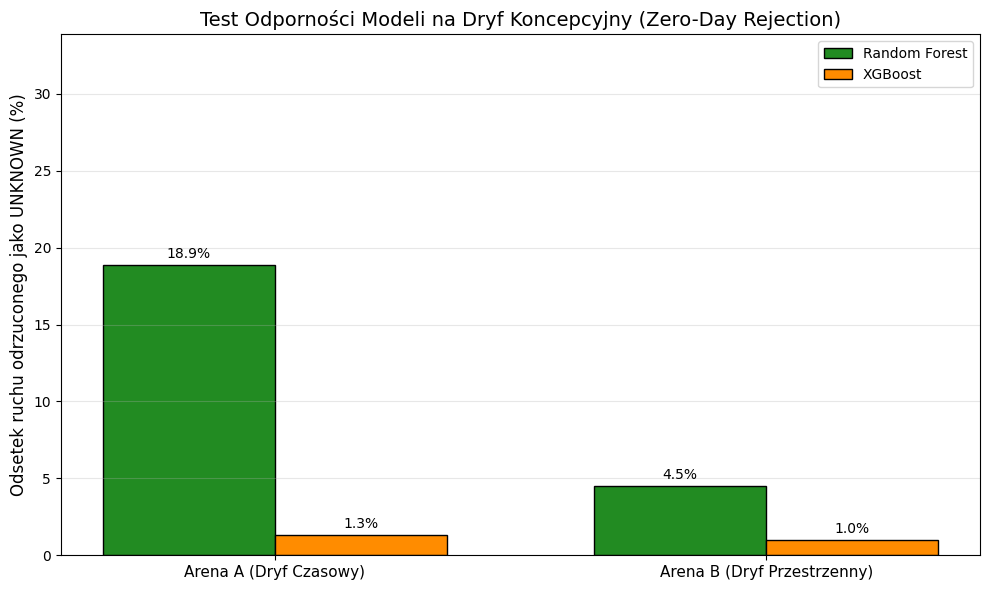

In [6]:
print("="*80)
print(">>> AKT 4: WIZUALIZACJA ZDOLNOŚCI ODRZUCANIA ZAGROŻEŃ (OOD DETECTION) <<<")
print("="*80)

try:
    labels = ['Arena A (Dryf Czasowy)', 'Arena B (Dryf Przestrzenny)']
    rf_rejects = [unknown_rf_A, unknown_rf_B]
    xgb_rejects = [unknown_xgb_A, unknown_xgb_B]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, rf_rejects, width, label='Random Forest', color='forestgreen', edgecolor='black')
    rects2 = ax.bar(x + width/2, xgb_rejects, width, label='XGBoost', color='darkorange', edgecolor='black')

    ax.set_ylabel('Odsetek ruchu odrzuconego jako UNKNOWN (%)', fontsize=12)
    ax.set_title('Test Odporności Modeli na Dryf Koncepcyjny (Zero-Day Rejection)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, max(max(rf_rejects), max(xgb_rejects)) + 15])

    # Dodanie etykiet nad słupkami
    ax.bar_label(rects1, padding=3, fmt='%.1f%%')
    ax.bar_label(rects2, padding=3, fmt='%.1f%%')

    plt.tight_layout()
    plt.savefig('../wykresy/12_zero_day_rejection_summary.png', dpi=300)
    print("[+] Zapisano wykres podsumowujący odrzuty (Zero-Day Rejection).")
    plt.show()
except NameError:
    print("[-] Uruchom najpierw komórki dla Areny A i Areny B, aby wygenerować wykres!")